In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [2]:
!pip install -q transformers>=4.37 accelerate timm
!pip install -q torch torchvision
!pip install -q opencv-python-headless albumentations
!pip install -q matplotlib tqdm scikit-learn
print("Done.")

Done.


In [3]:
import cv2, numpy as np
from pathlib import Path
from tqdm import tqdm
from tqdm.notebook import tqdm
from PIL import Image
import csv
import json
import os
import shutil
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn, torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation
from transformers import SegformerForSemanticSegmentation as SF

from concurrent.futures import ThreadPoolExecutor

In [4]:
DRIVE_ROOT    = '/content/drive/MyDrive/CVRoadMarkDetection/dataset'
TRAIN_IMG_DIR = os.path.join(DRIVE_ROOT, 'train/images')
TRAIN_LBL_DIR = os.path.join(DRIVE_ROOT, 'train/labels')
VALID_IMG_DIR = os.path.join(DRIVE_ROOT, 'valid/images')
VALID_LBL_DIR = os.path.join(DRIVE_ROOT, 'valid/labels')
TEST_IMG_DIR  = os.path.join(DRIVE_ROOT, 'test/images')
TEST_LBL_DIR  = os.path.join(DRIVE_ROOT, 'test/labels')

In [5]:
MASK_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/masks'
CKPT_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints'
for d in [MASK_DIR+'/train', MASK_DIR+'/valid', MASK_DIR+'/test', CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

CLASS_NAMES = [
    'BUS LANE', 'Yellow Markings', 'Line 1', 'Line 2',
    'Crossing', 'Romb', 'SLOW', 'Left Arrow',
    'Forward Arrow', 'Forward Arrow -Left', 'Forward Arrow -Right',
    'Right Arrow', 'Bicycle'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'NUM_CLASSES={NUM_CLASSES}')

NUM_CLASSES=13


In [6]:
def yolo_seg_to_mask(label_path, img_path, out_dir):
    if img_path and Path(img_path).exists():
        H, W = cv2.imread(str(img_path)).shape[:2]
    else:
        H, W = 640, 640  # fallback

    mask = np.zeros((H, W), dtype=np.uint8)
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid    = int(parts[0])
            coords = list(map(float, parts[1:]))
            pts    = np.array(
                [[int(coords[i]*W), int(coords[i+1]*H)]
                 for i in range(0, len(coords)-1, 2)],
                dtype=np.int32
            )
            if len(pts) >= 3:
                cv2.fillPoly(mask, [pts], color=int(cid + 1))  # 0=background

    out = Path(out_dir) / (Path(label_path).stem + '.png')
    cv2.imwrite(str(out), mask)

def convert_split(lbl_dir, img_dir, out_dir, name):
    files = list(Path(lbl_dir).glob('*.txt'))
    print(f'[{name}] {len(files)} label files...')
    for lbl in tqdm(files):
        img = next(
            (Path(img_dir)/(lbl.stem+ext)
             for ext in ['.jpg','.jpeg','.png','.JPG']
             if (Path(img_dir)/(lbl.stem+ext)).exists()),
            None
        )
        yolo_seg_to_mask(lbl, img, out_dir)
    print(f'  Done → {out_dir}')

# convert_split(TRAIN_LBL_DIR, TRAIN_IMG_DIR, MASK_DIR+'/train', 'train')
# convert_split(VALID_LBL_DIR, VALID_IMG_DIR, MASK_DIR+'/valid', 'valid')
# convert_split(TEST_LBL_DIR,  TEST_IMG_DIR,  MASK_DIR+'/test',  'test')

In [7]:
IMG_SIZE   = 512
BATCH_SIZE = 8

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    # A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(0.3, 0.3, p=0.4),
    A.GaussNoise(std_range=(0.04, 0.2), p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class RoadMarkDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, scan_labels=False):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        # 1. Find all image-mask pairs first (Fast)
        img_paths = []
        for ext in ['*.jpg','*.jpeg','*.png','*.JPG']:
            img_paths.extend(list(Path(img_dir).glob(ext)))
        img_paths = sorted(img_paths)

        valid_pairs = []
        for ip in img_paths:
            mp = Path(mask_dir) / (ip.stem + '.png')
            if mp.exists():
                valid_pairs.append((ip, mp))

        self.samples = valid_pairs

        # 2. Only scan masks if needed (e.g., for Training Sampler)
        if scan_labels:
            print(f"Scanning {len(self.samples)} masks for weights in {img_dir}...")

            def get_classes(paths):
                _, mp = paths
                mask_data = np.array(Image.open(mp))
                return np.unique(mask_data[mask_data > 0]) # Get non-zero classes

            # Use ThreadPool to speed up Google Drive I/O
            with ThreadPoolExecutor(max_workers=8) as executor:
                self.labels = list(tqdm(executor.map(get_classes, self.samples), total=len(self.samples)))

        print(f'  {len(self.samples)} samples found.')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        image  = np.array(Image.open(ip).convert('RGB'))
        mask   = np.array(Image.open(mp))
        if self.transform:
            a = self.transform(image=image, mask=mask)
            image, mask = a['image'], a['mask']
        return image.float(), mask.long()

# Only set scan_labels=True for the training set
print("Initializing Datasets...")
train_ds = RoadMarkDataset(TRAIN_IMG_DIR, MASK_DIR+'/train', train_tf, scan_labels=True)
val_ds   = RoadMarkDataset(VALID_IMG_DIR, MASK_DIR+'/valid', val_tf, scan_labels=False)
test_ds  = RoadMarkDataset(TEST_IMG_DIR,  MASK_DIR+'/test',  val_tf, scan_labels=False)

# --- SAMPLER LOGIC ---
print("Computing Sampler Weights...")
class_counts = np.zeros(NUM_CLASSES + 1)
for labels in train_ds.labels:
    for cls in labels:
        class_counts[cls] += 1

class_counts = np.maximum(class_counts, 1)
class_weights = 1.0 / class_counts

sample_weights = []
for labels in train_ds.labels:
    if len(labels) == 0:
        sample_weights.append(class_weights[0])
    else:
        # Weight based on the rarest class in the image
        weight = max([class_weights[cls] for cls in labels])
        sample_weights.append(weight)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# --- DATALOADERS ---
NUM_WORKERS = min(4, os.cpu_count())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, 1, shuffle=False)

print("DataLoaders ready with Weighted Sampler.")

Initializing Datasets...
Scanning 2167 masks for weights in /content/drive/MyDrive/CVRoadMarkDetection/dataset/train/images...


  0%|          | 0/2167 [00:00<?, ?it/s]

  2167 samples found.
  417 samples found.
  192 samples found.
Computing Sampler Weights...
DataLoaders ready with Weighted Sampler.


In [8]:
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
id2label = {0: 'background', **{i+1: CLASS_NAMES[i] for i in range(NUM_CLASSES)}}
label2id = {v: k for k, v in id2label.items()}

model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b2',
    num_labels             = NUM_CLASSES + 1,   # 14
    id2label               = id2label,
    label2id               = label2id,
    ignore_mismatched_sizes= True
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total/1e6:.1f}M on {DEVICE}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Total params: 27.4M on cuda


## **Loss Function Defination**

In [9]:
# class DiceLoss(nn.Module):
#     def __init__(self, smooth=1e-6):
#         super(DiceLoss, self).__init__()
#         self.smooth = smooth

#     def forward(self, logits, targets):
#         # logits: [N, C, H, W], targets: [N, H, W]
#         num_classes = logits.shape[1]

#         # Apply softmax to get probabilities
#         probs = F.softmax(logits, dim=1)

#         # Create one-hot targets: [N, C, H, W]
#         targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

#         # Flatten tensors for calculation
#         dims = (0, 2, 3)
#         intersection = torch.sum(probs * targets_one_hot, dim=dims)
#         cardinality = torch.sum(probs + targets_one_hot, dim=dims)

#         dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)

#         # We average the loss across classes (excluding background if desired)
#         return 1 - dice_score.mean()

# class CombinedLoss(nn.Module):
#     def __init__(self, weight=None):
#         super(CombinedLoss, self).__init__()
#         self.ce = nn.CrossEntropyLoss(weight=weight, ignore_index=255)
#         self.dice = DiceLoss()

#     def forward(self, logits, targets):
#         return ( 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets) )

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        """
        alpha: weight for False Positives (higher alpha penalizes FPs more)
        beta: weight for False Negatives (higher beta penalizes FNs more)
        """
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        fps = torch.sum(probs * (1 - targets_one_hot), dim=dims)
        fns = torch.sum((1 - probs) * targets_one_hot, dim=dims)

        tversky_score = (intersection + self.smooth) / (intersection + self.alpha * fps + self.beta * fns + self.smooth)

        return 1 - tversky_score.mean()

class CombinedLoss(nn.Module):
    def __init__(self, weight=None):
        super(CombinedLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, ignore_index=255)
        # Replacing Dice with Tversky
        self.tversky = TverskyLoss(alpha=0.7, beta=0.3)

    def forward(self, logits, targets):
        # You can adjust the 0.5/0.5 ratio if needed
        return ( 0.5 * self.ce(logits, targets) + 0.5 * self.tversky(logits, targets) )

In [10]:
WEIGHTS_PATH = os.path.join(CKPT_DIR, 'class_weights.pt')

def compute_class_weights(loader, n_cls, max_batches=60):
    freq = torch.zeros(n_cls)
    for i, (_, m) in enumerate(loader):
        if i >= max_batches: break
        for c in range(n_cls):
            freq[c] += (m == c).sum()
    freq = freq / freq.sum()
    w = 1.0 / (freq + 1e-6)
    return w / w.sum() * n_cls

if os.path.exists(WEIGHTS_PATH):
    print(f"Loading class weights from Drive: {WEIGHTS_PATH}")
    cw = torch.load(WEIGHTS_PATH).to(DEVICE)
else:
    print("Computing class weights...")
    cw = compute_class_weights(train_loader, NUM_CLASSES+1).to(DEVICE)
    torch.save(cw.cpu(), WEIGHTS_PATH)
    print(f"Class weights computed and saved to: {WEIGHTS_PATH}")

criterion = CombinedLoss(weight=cw)

backbone_p = [p for n,p in model.named_parameters() if 'segformer' in n]
head_p     = [p for n,p in model.named_parameters() if 'decode_head' in n]

NUM_EPOCHS = 97

optimizer  = AdamW([
    {'params': backbone_p, 'lr': 6e-5},
    {'params': head_p,     'lr': 6e-4}
], weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print(f"Ready: {NUM_EPOCHS} epochs.")

Loading class weights from Drive: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/class_weights.pt


model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

Ready: 200 epochs.


In [11]:
def compute_miou(preds, targets, n_cls):
    ious = []
    for c in range(1, n_cls):  # skip background
        p = (preds==c)
        t = (targets==c)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0: ious.append(inter/union)
    return sum(ious)/len(ious) if ious else 0.0

def evaluate(model, loader, n_cls, device):
    model.eval()
    tot_loss = tot_miou = n = 0
    val_pbar = tqdm(loader, desc='Validating: ', leave=False)

    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = F.interpolate(model(pixel_values=imgs).logits,
                                   size=masks.shape[-2:], mode='bilinear', align_corners=False)

            loss = criterion(logits, masks)
            tot_loss += loss.item()

            # Argmax for mIoU calculation
            preds = logits.argmax(1)
            miou = compute_miou(preds.cpu(), masks.cpu(), n_cls)
            tot_miou += miou
            n += 1

            # Update validation bar with live stats
            val_pbar.set_postfix(v_loss=f'{tot_loss/n:.4f}', v_miou=f'{tot_miou/n:.4f}')

    return tot_loss/n, tot_miou/n

In [12]:
BEST_CKPT = os.path.join(CKPT_DIR, 'segformer_best.pth')
RUNNING_CKPT = os.path.join(CKPT_DIR, 'segformer_running.pth')
history_csv_path = os.path.join(CKPT_DIR, 'training_history.csv')

# CSV Initialization

headers = ['epoch', 'train_loss', 'val_loss', 'train_miou', 'val_miou']

if not os.path.exists(history_csv_path):
    with open(history_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
    print(f"Created new history file: {history_csv_path}")
else:
    print(f"History file found. Data will be appended to: {history_csv_path}")

history = {k:[] for k in ['train_loss','val_loss','train_miou','val_miou']}

checkpoint_to_load = RUNNING_CKPT if os.path.exists(RUNNING_CKPT) else (BEST_CKPT if os.path.exists(BEST_CKPT) else None)

if checkpoint_to_load:
    print(f"Loading Checkpoint from: {checkpoint_to_load}")
    checkpoint = torch.load(checkpoint_to_load)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch']
    stored_best = checkpoint.get('best_miou', 0.0)
    current_miou = checkpoint.get('miou', 0.0)
    best_miou = max(stored_best, current_miou)

    if 'history' in checkpoint:
        history = checkpoint['history']

    print(f"Resuming from Epoch {start_epoch} (Last mIoU: {current_miou:.4f}, Best mIoU: {best_miou:.4f})")
else:
    print("No checkpoint found. Starting from scratch.")
    start_epoch = 0
    best_miou = 0.0

patience = 15
counter = 0
early_stop = False

total_limit = NUM_EPOCHS

if start_epoch >= total_limit:
    print(f"Model already trained.")
else:
  for epoch in range(start_epoch + 1, total_limit + 1):
      model.train()
      ep_loss = ep_miou = n = 0
      pbar = tqdm(train_loader, desc=f'Ep {epoch:02d}/{total_limit}', leave=False)

      # for imgs, masks in pbar:
      #     imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
      #     optimizer.zero_grad()
      #     logits = F.interpolate(model(pixel_values=imgs).logits,
      #                           size=masks.shape[-2:], mode='bilinear', align_corners=False)
      #     loss = criterion(logits, masks)
      #     loss.backward()
      #     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      #     optimizer.step();
      #     ep_loss += loss.item()
      #     ep_miou += compute_miou(logits.detach().argmax(1).cpu(), masks.cpu(), NUM_CLASSES+1)
      #     n += 1
      #     pbar.set_postfix(loss=f'{ep_loss/n:.4f}', miou=f'{ep_miou/n:.4f}')

      scaler = torch.amp.GradScaler('cuda')

      for imgs, masks in pbar:
          imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
          optimizer.zero_grad()

          # 1. Forward pass with autocast
          with torch.amp.autocast('cuda'):
              logits = F.interpolate(model(pixel_values=imgs).logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)
              loss = criterion(logits, masks)

          # 2. Scale the loss and do backward pass
          scaler.scale(loss).backward()

          # 3. Unscale gradients BEFORE clipping
          scaler.unscale_(optimizer)

          # 4. Clip gradients (now that they are unscaled)
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

          # 5. Scaler step and update
          scaler.step(optimizer)
          scaler.update()

          # --- Metrics ---
          ep_loss += loss.item()
          # Use .detach() and argmax on logits for metrics
          ep_miou += compute_miou(logits.detach().argmax(1).cpu(), masks.cpu(), NUM_CLASSES+1)
          n += 1
          pbar.set_postfix(loss=f'{ep_loss/n:.4f}', miou=f'{ep_miou/n:.4f}')

      tl, tm = ep_loss/n, ep_miou/n
      vl, vm = evaluate(model, val_loader, NUM_CLASSES+1, DEVICE)

      scheduler.step(vm)

      history['train_loss'].append(tl)
      history['val_loss'].append(vl)
      history['train_miou'].append(tm)
      history['val_miou'].append(vm)

      # 1. Update CSV
      with open(history_csv_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, tl, vl, tm, vm])

      print(f'Ep {epoch:02d} | Train L:{tl:.4f} mIoU:{tm:.4f} | Val L:{vl:.4f} mIoU:{vm:.4f}')

      # 2. SAVE RUNNING CHECKPOINT (Every Epoch)
      checkpoint_data = {
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'scheduler_state_dict': scheduler.state_dict(),
          'miou': vm,
          'best_miou': best_miou,
          'history': history
      }
      torch.save(checkpoint_data, RUNNING_CKPT)

      # 3. SAVE BEST CHECKPOINT (Only if improved)
      if vm > best_miou:
          best_miou = vm
          counter = 0
          torch.save(checkpoint_data, BEST_CKPT)
          print(f'  ✓ New Best saved (val mIoU={best_miou:.4f})')
      else:
          counter += 1
          print(f'  × No improvement for {counter} epoch(s). Running checkpoint updated.')
          if counter >= patience:
              print(f'!!! Early stopping triggered at epoch {epoch} !!!')
              early_stop = True

      if early_stop:
          break

print(f'Training done. Best val mIoU = {best_miou:.4f}')

History file found. Data will be appended to: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/training_history.csv
Loading Checkpoint from: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/segformer_running.pth
Resuming from Epoch 94 (Last mIoU: 0.6537, Best mIoU: 0.6569)


Ep 95/200:   0%|          | 0/271 [00:00<?, ?it/s]

Validating:   0%|          | 0/53 [00:00<?, ?it/s]

Ep 95 | Train L:0.1309 mIoU:0.7562 | Val L:0.4541 mIoU:0.6531
  × No improvement for 13 epoch(s). Running checkpoint updated.


Ep 96/200:   0%|          | 0/271 [00:00<?, ?it/s]

Validating:   0%|          | 0/53 [00:00<?, ?it/s]

Ep 96 | Train L:0.1441 mIoU:0.7581 | Val L:0.4637 mIoU:0.6564
  × No improvement for 14 epoch(s). Running checkpoint updated.


Ep 97/200:   0%|          | 0/271 [00:00<?, ?it/s]

Validating:   0%|          | 0/53 [00:00<?, ?it/s]

Ep 97 | Train L:0.1209 mIoU:0.7635 | Val L:0.4584 mIoU:0.6492
  × No improvement for 15 epoch(s). Running checkpoint updated.
!!! Early stopping triggered at epoch 97 !!!
Training done. Best val mIoU = 0.6569


In [24]:
import torch
import numpy as np
from tqdm import tqdm
import os

# --- 1. CONFIGURATION & WEIGHT LOADING ---
# Path to your best checkpoint
CHECKPOINT_PATH = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/segformer_best.pth'

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading weights from: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model loaded. Best mIoU (from training): {checkpoint.get('best_miou', 'N/A'):.4f}")
else:
    print(f"ERROR: Checkpoint not found at {CHECKPOINT_PATH}.")

# --- 2. CLASS-WISE IoU FUNCTION ---
def get_class_wise_iou(model, loader, num_classes, device):
    model.eval()
    total_inter = torch.zeros(num_classes).to(device)
    total_union = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating Validation Set"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(pixel_values=imgs)
            logits = torch.nn.functional.interpolate(
                outputs.logits, size=masks.shape[-2:], mode='bilinear', align_corners=False
            )
            preds = logits.argmax(1)

            for c in range(num_classes):
                p = (preds == c)
                t = (masks == c)
                total_inter[c] += (p & t).sum().item()
                total_union[c] += (p | t).sum().item()

    ious = total_inter / (total_union + 1e-6)
    return ious.cpu().numpy()

# --- 3. RUN EVALUATION ---
# NUM_CLASSES + 1 because index 0 is background
class_ious = get_class_wise_iou(model, val_loader, NUM_CLASSES + 1, DEVICE)

# --- 4. DISPLAY RESULTS ---
print(f"\n{'Class Name':<25} | {'IoU':<10}")
print("-" * 38)

# Print all classes (excluding background from the mean later)
for i, iou_val in enumerate(class_ious):
    class_name = id2label[i]
    print(f"{class_name:<25} | {iou_val:.4f}")

# Calculate Mean IoU specifically for foreground classes (indices 1 to 13)
foreground_ious = class_ious[1:]
mean_foreground_iou = np.mean(foreground_ious)

print("-" * 38)
print(f"{'MEAN IoU (Foreground Only)':<25} | {mean_foreground_iou:.4f}")

Loading weights from: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/segformer_best.pth
Model loaded. Best mIoU (from training): 0.6554


Evaluating Validation Set: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s]


Class Name                | IoU       
--------------------------------------
background                | 0.9871
BUS LANE                  | 0.6712
Yellow Markings           | 0.8561
Line 1                    | 0.5402
Line 2                    | 0.5380
Crossing                  | 0.6991
Romb                      | 0.7775
SLOW                      | 0.8115
Left Arrow                | 0.7429
Forward Arrow             | 0.6557
Forward Arrow -Left       | 0.5502
Forward Arrow -Right      | 0.8312
Right Arrow               | 0.7871
Bicycle                   | 0.8726
--------------------------------------
MEAN IoU (Foreground Only) | 0.7179


Successfully loaded history with 97 epochs.


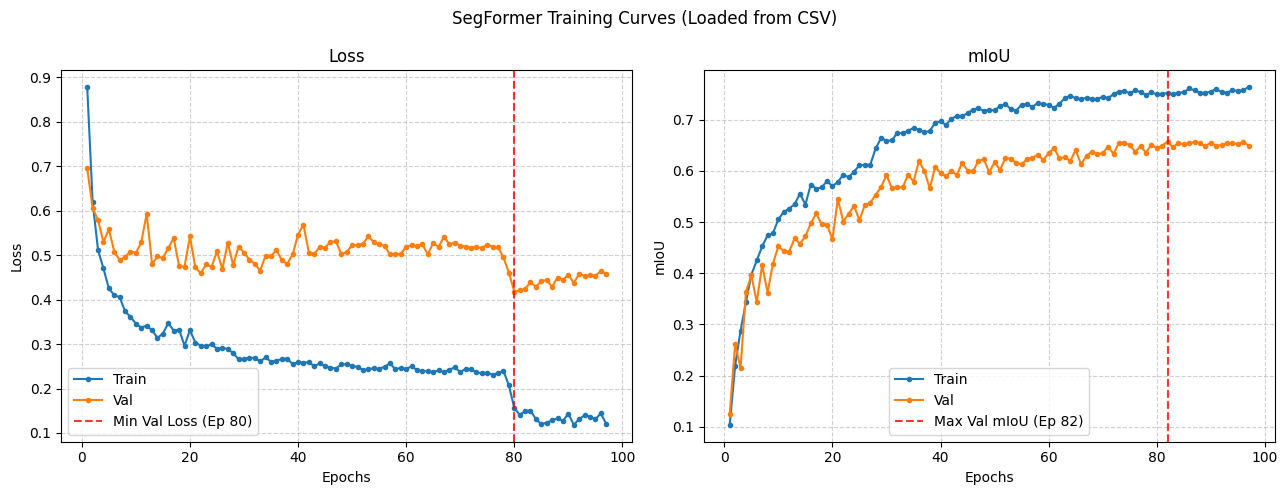

Plot updated and saved to: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/checkpoints/training_curves.png


In [14]:
history_csv_path = os.path.join(CKPT_DIR, 'training_history.csv')

if os.path.exists(history_csv_path):
    # 1. Load the data using pandas
    df = pd.read_csv(history_csv_path)
    print(f"Successfully loaded history with {len(df)} epochs.")

    # Find the optimal epochs
    best_loss_epoch = df.loc[df['val_loss'].idxmin(), 'epoch']
    best_miou_epoch = df.loc[df['val_miou'].idxmax(), 'epoch']

    # 2. Plotting Logic
    ep = df['epoch']
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

    # --- Loss Curve ---
    a1.plot(ep, df['train_loss'], label='Train', marker='o', markersize=3)
    a1.plot(ep, df['val_loss'], label='Val', marker='o', markersize=3)
    # Vertical line for lowest Val Loss
    a1.axvline(x=best_loss_epoch, color='red', linestyle='--', alpha=0.8, label=f'Min Val Loss (Ep {int(best_loss_epoch)})')

    a1.set_title('Loss')
    a1.set_xlabel('Epochs')
    a1.set_ylabel('Loss')
    a1.legend()
    a1.grid(True, linestyle='--', alpha=0.6)

    # --- mIoU Curve ---
    a2.plot(ep, df['train_miou'], label='Train', marker='o', markersize=3)
    a2.plot(ep, df['val_miou'], label='Val', marker='o', markersize=3)
    # Vertical line for highest Val mIoU
    a2.axvline(x=best_miou_epoch, color='red', linestyle='--', alpha=0.8, label=f'Max Val mIoU (Ep {int(best_miou_epoch)})')

    a2.set_title('mIoU')
    a2.set_xlabel('Epochs')
    a2.set_ylabel('mIoU')
    a2.legend()
    a2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('SegFormer Training Curves (Loaded from CSV)')
    plt.tight_layout()

    # Save back to Drive
    plot_path = os.path.join(os.path.dirname(history_csv_path), 'training_curves.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Plot updated and saved to: {plot_path}")

else:
    print(f"Error: Could not find history file at {history_csv_path}. Run the training loop first!")

In [15]:
# Load the checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)

# Fix: Use 'model_state_dict' instead of 'state'
# based on your saving logic in Cell 10
model.load_state_dict(ckpt['model_state_dict'])

print(f'Loaded epoch {ckpt["epoch"]} (val mIoU={ckpt["miou"]:.4f})')

def per_class_iou(model, loader, n_cls, device):
    model.eval()
    inter = torch.zeros(n_cls)
    union = torch.zeros(n_cls)
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Testing'):
            # Standard SegFormer forward pass
            outputs = model(pixel_values=imgs.to(device))

            # Upscale logits to match the ground truth mask size
            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            preds = logits.argmax(1).cpu()
            for c in range(n_cls):
                p = (preds == c)
                t = (masks == c)
                inter[c] += (p & t).sum()
                union[c] += (p | t).sum()

    return inter / (union + 1e-6)

# Execute evaluation
iou = per_class_iou(model, test_loader, NUM_CLASSES + 1, DEVICE)
mean_iou = iou[1:].mean().item()  # Calculate mean across foreground classes

# Print results
print(f'\n{"Class":<28} {"IoU":>8}')
print('-' * 38)
for i, nm in enumerate(['background'] + CLASS_NAMES):
    print(f'{nm:<28} {iou[i].item():.4f}')

print(f'\nmIoU (foreground): {mean_iou:.4f}')

Loaded epoch 82 (val mIoU=0.6569)


Testing: 100%|██████████| 192/192 [05:20<00:00,  1.67s/it]


Class                             IoU
--------------------------------------
background                   0.9889
BUS LANE                     0.7712
Yellow Markings              0.9054
Line 1                       0.5451
Line 2                       0.4868
Crossing                     0.7296
Romb                         0.7509
SLOW                         0.7955
Left Arrow                   0.7949
Forward Arrow                0.7851
Forward Arrow -Left          0.7553
Forward Arrow -Right         0.7923
Right Arrow                  0.7783
Bicycle                      0.2887

mIoU (foreground): 0.7061


In [16]:
baseline = SF.from_pretrained('nvidia/mit-b2', num_labels=NUM_CLASSES+1,
    id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True).to(DEVICE)

b_iou   = per_class_iou(baseline, test_loader, NUM_CLASSES+1, DEVICE)
b_miou  = b_iou[1:].mean().item()

print(f'\nBaseline mIoU  (no fine-tune) : {b_miou:.4f}')
print(f'Fine-tuned mIoU               : {mean_iou:.4f}')
print(f'Improvement                   : +{mean_iou-b_miou:.4f}')

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


Baseline mIoU  (no fine-tune) : 0.0060
Fine-tuned mIoU               : 0.7061
Improvement                   : +0.7001


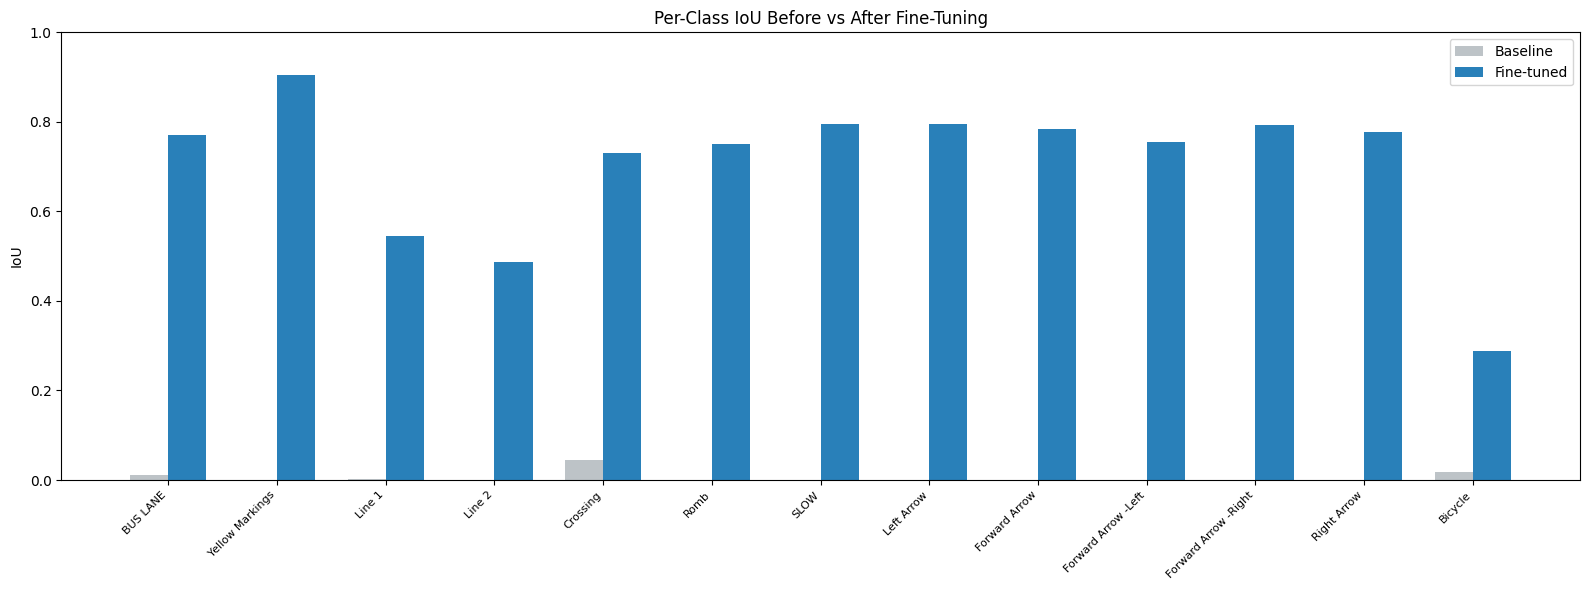

In [17]:
fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.set_facecolor('none')
x = np.arange(NUM_CLASSES); w = 0.35
ax.bar(x-w/2, b_iou[1:].numpy(), w, label='Baseline', color='#bdc3c7')
ax.bar(x+w/2, iou[1:].numpy(),   w, label='Fine-tuned', color='#2980b9')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0,1); ax.set_ylabel('IoU'); ax.legend()
ax.set_title('Per-Class IoU Before vs After Fine-Tuning')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training6/transfer_learning_comparison.png', dpi=150); plt.show()

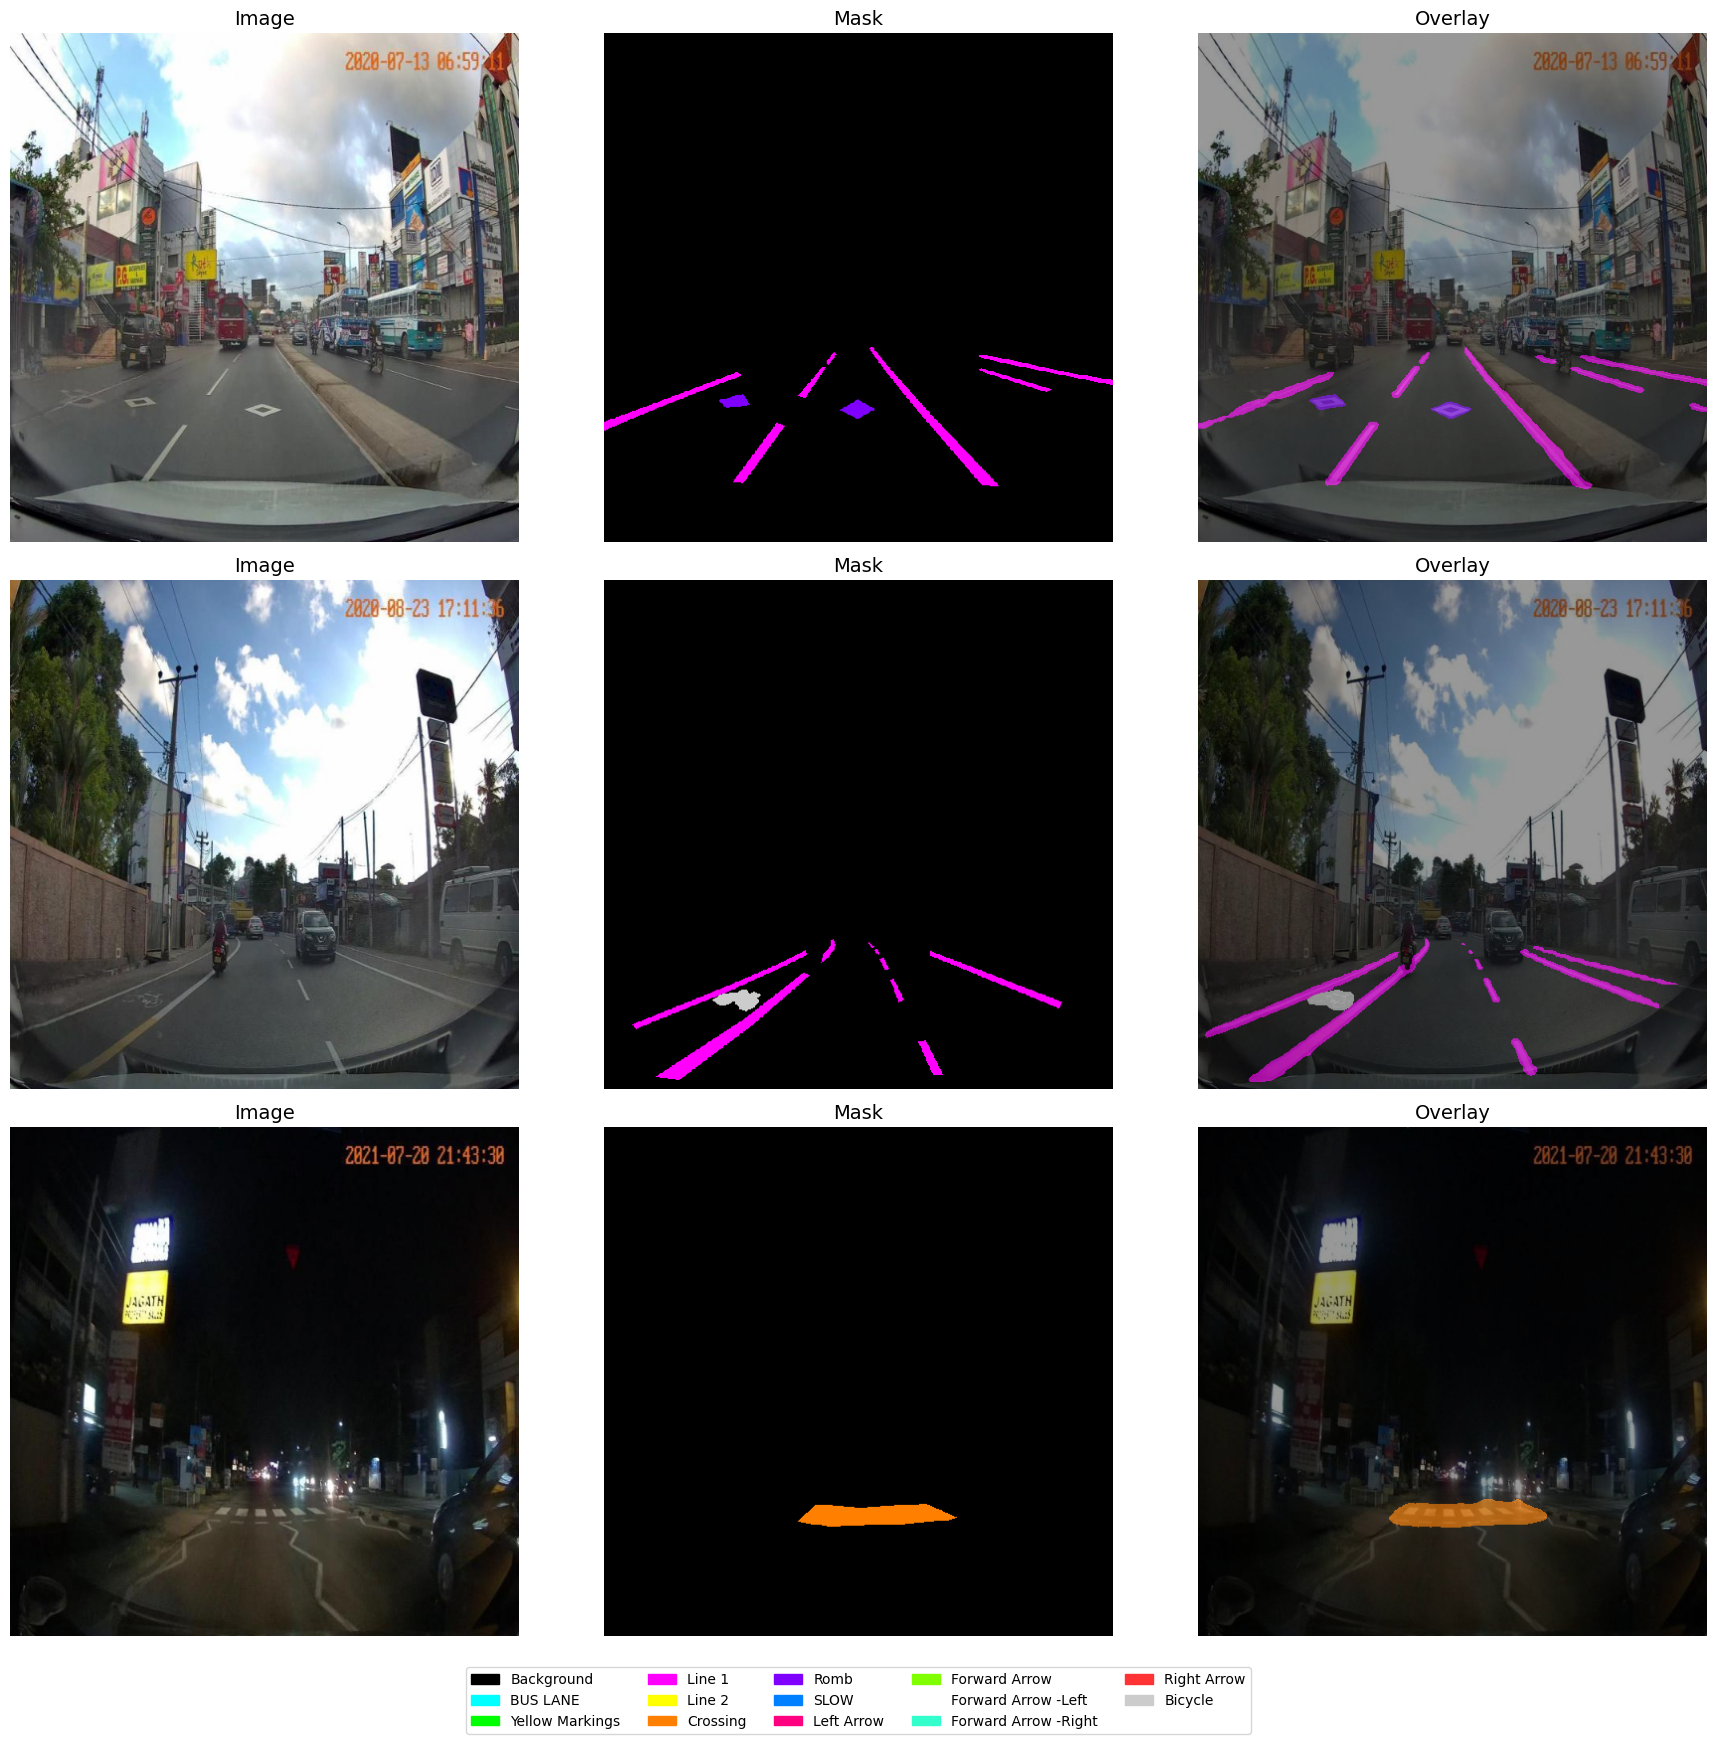

In [18]:
def visualize_neon_grid(model, dataset, device, class_names):
    model.eval()
    n_samples = 3

    # 1. Define Neon Colors (RGB normalized 0-1)
    # Background is Black [0,0,0]
    # Markings use vibrant Cyan, Lime, Magenta, Yellow, Orange, etc.
    neon_colors = [
        [0, 0, 0],           # 0: Background (Black)
        [0, 1, 1],           # 1: Cyan
        [0, 1, 0],           # 2: Lime
        [1, 0, 1],           # 3: Magenta
        [1, 1, 0],           # 4: Yellow
        [1, 0.5, 0],         # 5: Orange
        [0.5, 0, 1],         # 6: Purple
        [0, 0.5, 1],         # 7: Sky Blue
        [1, 0, 0.5],         # 8: Hot Pink
        [0.5, 1, 0],         # 9: Chartreuse
        [1, 1, 1],           # 10: White
        [0.2, 1, 0.8],       # 11: Aquamarine
        [1, 0.2, 0.2],       # 12: Neon Red
        [0.8, 0.8, 0.8]      # 13: Silver/Grey
    ]

    # Ensure we have enough colors for all classes
    while len(neon_colors) < len(class_names) + 1:
        neon_colors.append(list(np.random.random(3)))

    custom_cmap = ListedColormap(neon_colors[:len(class_names)+1])

    fig, axes = plt.subplots(n_samples, 3, figsize=(18, 18), facecolor='white')

    import random

    # indices = range(n_samples) # Or random.sample(range(len(dataset)), n_samples)
    indices = random.sample(range(len(dataset)), n_samples) # Or random.sample(range(len(dataset)), n_samples)

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        # Inference
        input_tensor = image.unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(pixel_values=input_tensor)
            logits = F.interpolate(outputs.logits, size=mask.shape[-2:],
                                   mode='bilinear', align_corners=False)
            prediction = logits.argmax(1).squeeze(0).cpu().numpy()

        # Reverse Normalization
        img_vis = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_vis = (img_vis * std + mean).clip(0, 1)

        pred_colored = custom_cmap(prediction)

        pred_colored[prediction == 0, 3] = 0.4
        pred_colored[prediction > 0, 3] = 0.6

        # --- Column 0: Image ---
        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title("Image", fontsize=14)
        axes[i, 0].axis("off")

        # --- Column 1: Mask (Black Background + Neon) ---
        axes[i, 1].imshow(mask.cpu().numpy(), cmap=custom_cmap, vmin=0, vmax=len(class_names))
        axes[i, 1].set_title("Mask", fontsize=14)
        axes[i, 1].axis("off")

        # --- Column 2: Overlay ---
        axes[i, 2].imshow(img_vis)
        axes[i, 2].imshow(pred_colored)
        # axes[i, 2].imshow(pred_colored, alpha=mask_alpha)
        axes[i, 2].set_title("Overlay", fontsize=14)
        axes[i, 2].axis("off")

    # Legend Construction
    full_classes = ['Background'] + class_names
    legend_patches = [
        mpatches.Patch(color=neon_colors[j], label=full_classes[j])
        for j in range(len(full_classes))
    ]

    fig.legend(handles=legend_patches, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, 0.03), fontsize='medium', frameon=True)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# Execution
visualize_neon_grid(model, test_ds, DEVICE, CLASS_NAMES)

In [19]:
@torch.no_grad()
def process_segformer_video_labeled(model_ckpt, input_path, output_path, device=DEVICE):
    # Ensure the directory exists
    output_dir = os.path.dirname(output_path)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    # 1. Load Model
    model.load_state_dict(torch.load(model_ckpt, map_location=device)['model_state_dict'])
    model.eval()

    # 2. Open Video
    cap = cv2.VideoCapture(input_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 3. Setup Header (Extra space at the top for labels)
    header_h = 60  # Height of the black bar for text labels
    combined_width = width * 3
    combined_height = height + header_h

    # 4. Video Writer Setup
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (combined_width, combined_height))

    # 5. Color Palette
    neon_colors = np.array([
        [0, 0, 0], [0, 255, 255], [0, 255, 0], [255, 0, 255], [255, 255, 0],
        [255, 128, 0], [128, 0, 255], [0, 128, 255], [255, 0, 128], [128, 255, 0],
        [255, 255, 255], [50, 255, 200], [255, 50, 50], [200, 200, 200]
    ], dtype=np.uint8)

    print(f"Processing labeled comparison: {total_frames} frames...")

    for _ in tqdm(range(total_frames)):
        ret, frame = cap.read()
        if not ret: break

        # --- Inference Logic ---
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        augmented = val_tf(image=frame_rgb)
        input_tensor = augmented['image'].unsqueeze(0).to(device)
        outputs = model(pixel_values=input_tensor)

        logits = F.interpolate(outputs.logits, size=(height, width), mode='bilinear', align_corners=False)
        pred = logits.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)

        # --- View 1: Original ---
        view1 = frame.copy()

        # --- View 2: Original + Pred Seg Mask (Overlay) ---
        mask_rgb = neon_colors[pred]
        mask_bgr = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR)
        alpha = 0.5
        binary_mask = (pred > 0).astype(np.float32)[:, :, np.newaxis]
        marking_areas = (mask_bgr * alpha + frame * (1 - alpha)).astype(np.uint8)
        view2 = np.where(binary_mask == 1, marking_areas, frame)

        # --- View 3: Pred Mask Only ---
        view3 = mask_bgr

        # --- Combine and Label ---
        # Create a blank canvas for the header + frames
        canvas = np.zeros((combined_height, combined_width, 3), dtype=np.uint8)

        # Place frames below the header area
        canvas[header_h:, 0:width] = view1
        canvas[header_h:, width:width*2] = view2
        canvas[header_h:, width*2:width*3] = view3

        # Add Labels
        labels = ["Original Video", "Original + Predicted Segmented Mask", "Predicted Mask"]
        for i, text in enumerate(labels):
            # Centering logic for text
            text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)[0]
            text_x = (i * width) + (width - text_size[0]) // 2
            cv2.putText(canvas, text, (text_x, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2, cv2.LINE_AA)

        out.write(canvas)

    cap.release()
    out.release()
    print(f"\nLabeled video saved to: {output_path}")


# --- EXECUTION ---
INPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/5.mp4'
OUTPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/SegFormer/5_Comparison_3Panel.mp4'

# process_segformer_video_labeled(BEST_CKPT, INPUT_VID, OUTPUT_VID)

In [20]:
import os
from pathlib import Path
from collections import Counter

# 1. Define paths and class names as per your notebook
TRAIN_LBL_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/dataset/train/labels'
CLASS_NAMES = [
    'BUS LANE', 'Yellow Markings', 'Line 1', 'Line 2',
    'Crossing', 'Romb', 'SLOW', 'Left Arrow',
    'Forward Arrow', 'Forward Arrow -Left', 'Forward Arrow -Right',
    'Right Arrow', 'Bicycle'
]

def get_sorted_class_counts(label_dir, class_names):
    """
    Counts images per class and returns a list of tuples
    sorted from highest count to lowest.
    """
    class_counts = Counter()
    label_files = list(Path(label_dir).glob('*.txt'))

    for lbl in label_files:
        # A set is used so that if a class appears multiple times
        # in one image, it is only counted as 1 image for that class.
        classes_in_image = set()
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    classes_in_image.add(class_id)

        for cid in classes_in_image:
            class_counts[cid] += 1

    # Create a list of (Class Name, Count)
    results = []
    for i, name in enumerate(class_names):
        results.append((name, class_counts[i]))

    # Sort by count (the second element of the tuple) in descending order
    results.sort(key=lambda x: x[1], reverse=True)

    return results

# 2. Run the counting function
sorted_stats = get_sorted_class_counts(TRAIN_LBL_DIR, CLASS_NAMES)

# 3. Print the results (Highest to Lowest)
print(f"{'Class Name':<25} | {'Image Count'}")
print("-" * 40)
for name, count in sorted_stats:
    print(f"{name:<25} | {count}")

Class Name                | Image Count
----------------------------------------
Line 1                    | 1133
Forward Arrow             | 729
Crossing                  | 672
Romb                      | 356
Right Arrow               | 250
Forward Arrow -Left       | 185
BUS LANE                  | 181
Line 2                    | 163
Yellow Markings           | 138
Left Arrow                | 124
Bicycle                   | 65
Forward Arrow -Right      | 62
SLOW                      | 49
